In [1]:
import utils
import models
import dataset
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2


In [2]:
X, Y = dataset.load_data()
X_train, Y_train, X_test, Y_test = dataset.partition_data(X, Y, split_ratio = [.8, .2])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
end_plot = 1000


Epoch 1/20 | Train Loss: 0.8573 | Val Loss: 0.8814
Epoch 3/20 | Train Loss: 0.7630 | Val Loss: 0.8406
Epoch 5/20 | Train Loss: 0.7513 | Val Loss: 0.8334
Epoch 7/20 | Train Loss: 0.7453 | Val Loss: 0.8284
Epoch 9/20 | Train Loss: 0.7412 | Val Loss: 0.8258
Epoch 11/20 | Train Loss: 0.7390 | Val Loss: 0.8233
Epoch 13/20 | Train Loss: 0.7368 | Val Loss: 0.8219
Epoch 15/20 | Train Loss: 0.7355 | Val Loss: 0.8211
Epoch 17/20 | Train Loss: 0.7335 | Val Loss: 0.8190
Epoch 19/20 | Train Loss: 0.7324 | Val Loss: 0.8174
Epoch 20/20 | Train Loss: 0.7316 | Val Loss: 0.8173


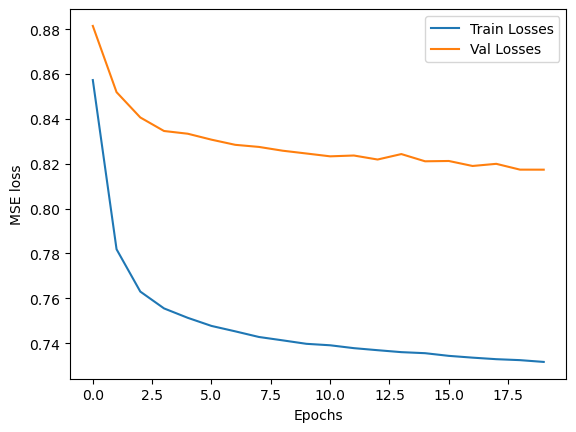

In [3]:
lstm = models.LSTM(epochs = 20)

lstm.train_model(X_train, Y_train, plot = True)

lstm_yhat = lstm.run_model(X_test)

Epoch 1/20 | Train Loss: 0.8120 | Val Loss: 0.8524
Epoch 3/20 | Train Loss: 0.7497 | Val Loss: 0.8305
Epoch 5/20 | Train Loss: 0.7398 | Val Loss: 0.8250
Epoch 7/20 | Train Loss: 0.7346 | Val Loss: 0.8233
Epoch 9/20 | Train Loss: 0.7304 | Val Loss: 0.8196
Epoch 11/20 | Train Loss: 0.7282 | Val Loss: 0.8190
Epoch 13/20 | Train Loss: 0.7250 | Val Loss: 0.8166
Epoch 15/20 | Train Loss: 0.7231 | Val Loss: 0.8173
Epoch 17/20 | Train Loss: 0.7212 | Val Loss: 0.8149
Epoch 19/20 | Train Loss: 0.7195 | Val Loss: 0.8150
Epoch 20/20 | Train Loss: 0.7193 | Val Loss: 0.8137


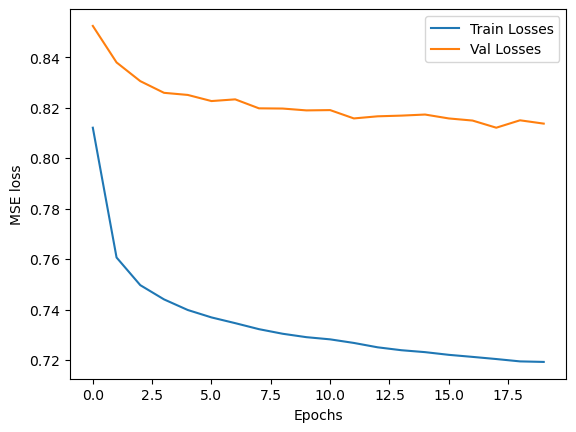

In [4]:
mlp = models.MLP(epochs = 20)

mlp.train_model(X_train, Y_train)

mlp_yhat = mlp.run_model(X_test)

In [5]:
kf = models.KalmanFilter()

kf.train_model(X_train, Y_train)

kf_yhat = kf.run_model(X_test, Y_test[0, :])

In [6]:
# kNet = models.KalmanNet() 

# kNet.train_model(X_train, Y_train)

# kNet_yhat = kNet.run_model(X_test, Y_test[0, :])

c:\Users\jkanetis\OneDrive - Umich\Michigan\Winter 2025\EECS 545\EECS545FinalProject\models.py:125: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.theta, _, _, _ = np.linalg.lstsq(np.matmul(X.T, X) + self.lbda*np.eye(X.shape[1]), np.matmul(X.T, Y))
c:\Users\jkanetis\OneDrive - Umich\Michigan\Winter 2025\EECS 545\EECS545FinalProject\models.py:125: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.theta, _, _, _ = np.linalg.lstsq(np.matmul(X.T, X) + self.lbda*np.eye(X.shape[1]), np.matmul(X.T, Y))


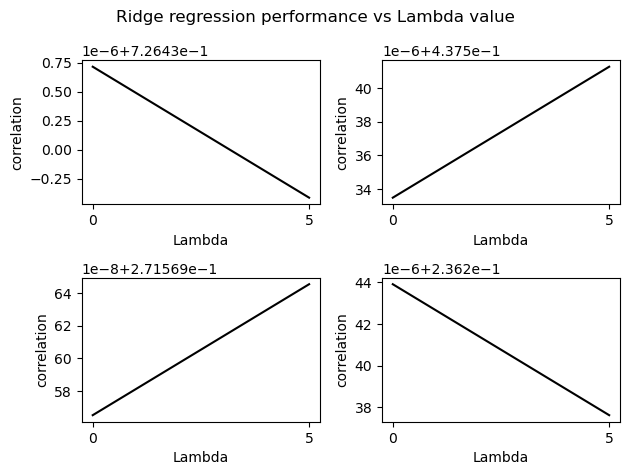

In [7]:
rr = models.RidgeRegression()

rr.train_model(X_train, Y_train)

RR_yhat = rr.run_model(X_test, Y_test[0, :])

In [8]:
lr = models.RidgeRegression(lbda=1)

lr.train_model(X_train, Y_train)

lr_yhat = lr.run_model(X_test, Y_test[0, :])

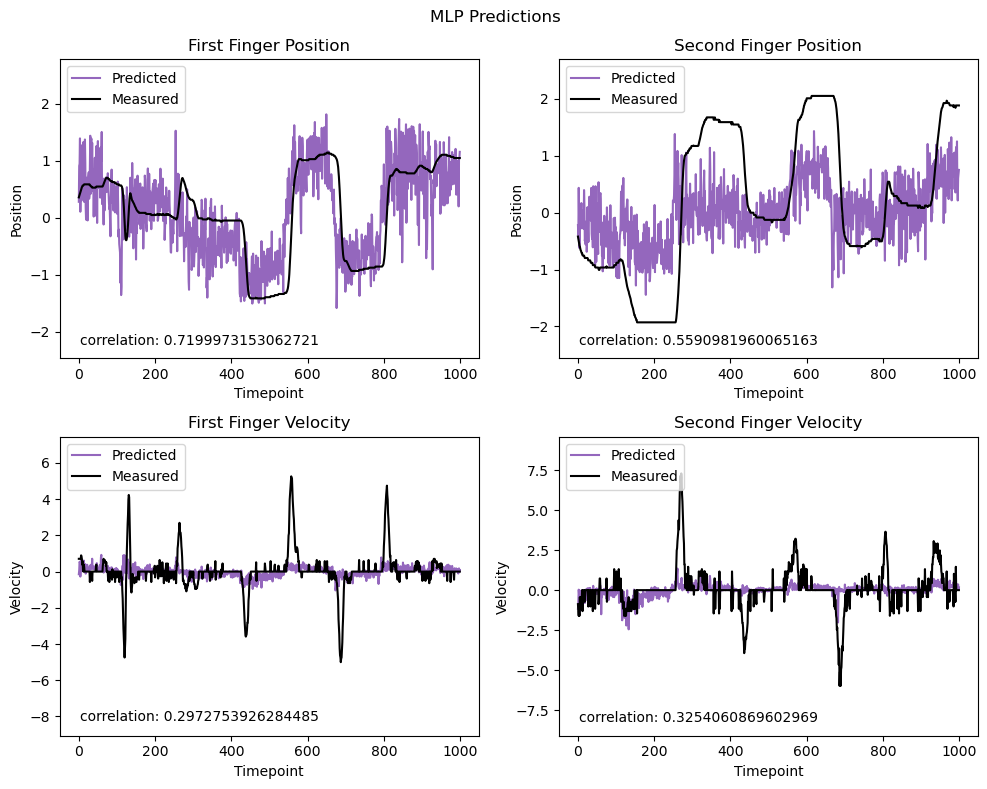

In [9]:
#utils.plot_predictions(Y_test, lstm_yhat, title = f"{lstm.name} Predictions", color = colors[0], end = end_plot)
utils.plot_predictions(Y_test, mlp_yhat, title = f"{mlp.name} Predictions", color = colors[4], end = end_plot)
#utils.plot_predictions(Y_test, kNet_yhat, title = f"{kNet.name} Predictions", color = colors[1], end = end_plot)
# utils.plot_predictions(Y_test, RR_yhat, title = f"{rr.name} Predictions", color = colors[2], end = end_plot)
# utils.plot_predictions(Y_test, lr_yhat, title = f"{lr.name} Predictions", color = colors[3], end = end_plot)

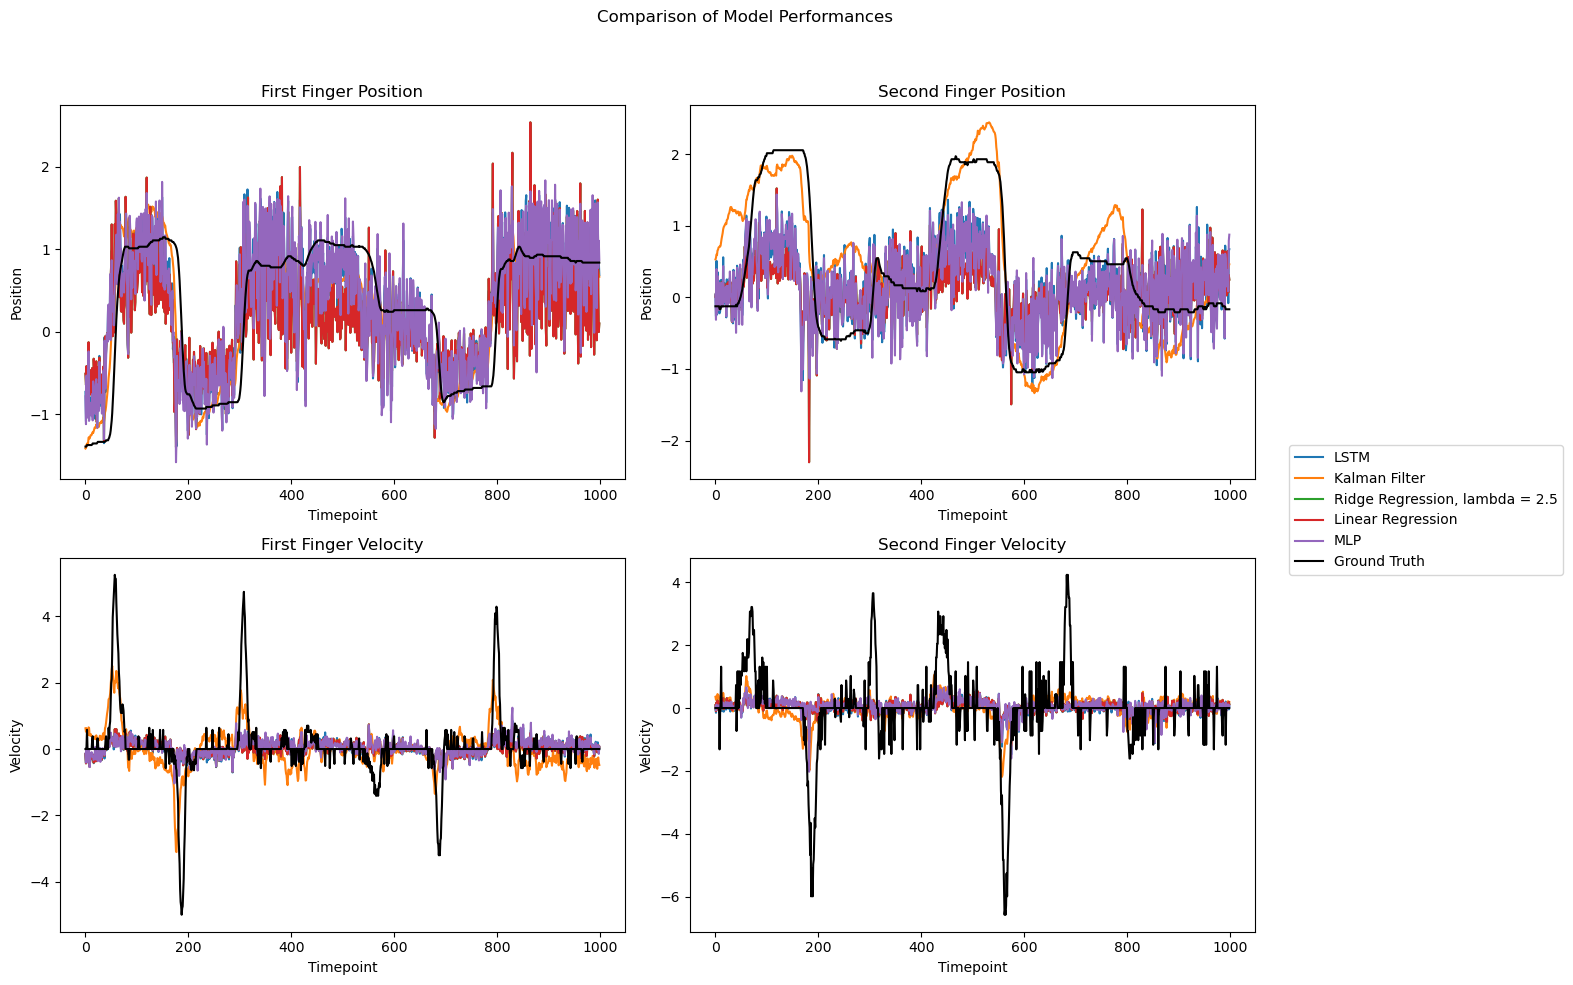

In [10]:
start = 500
utils.compare_perfs(Y_test, yhats = [lstm_yhat, kf_yhat, RR_yhat, lr_yhat, mlp_yhat], model_labels = [lstm.name, kf.name, rr.name, lr.name, mlp.name], colors = colors, start = start, end = start+end_plot)

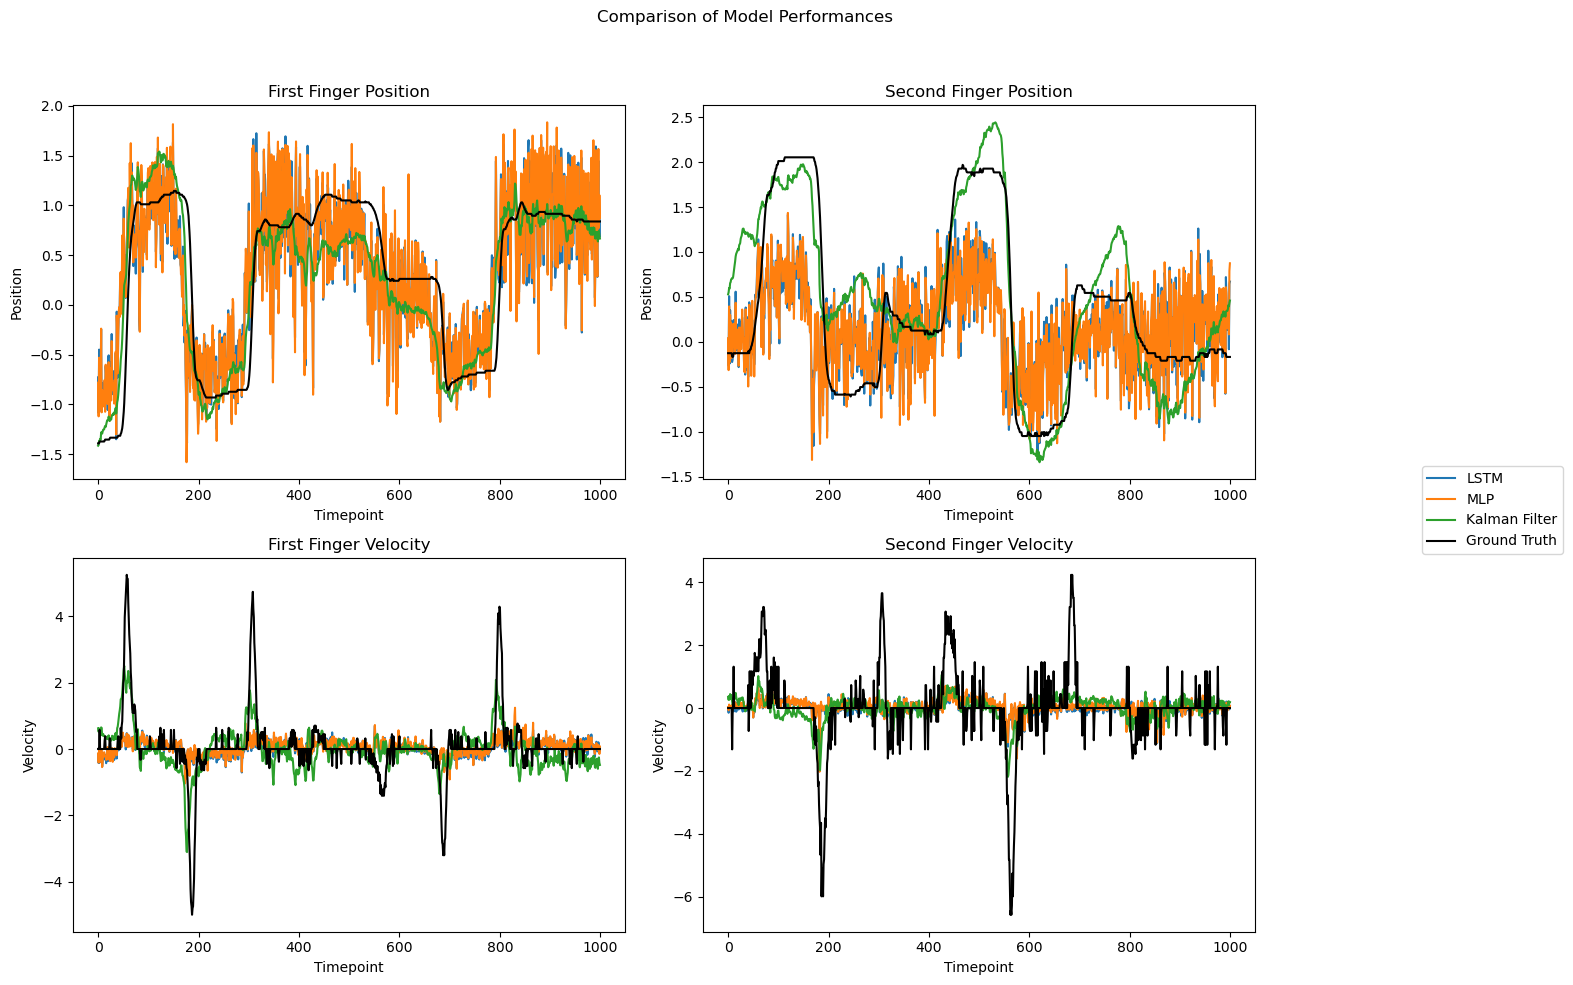

In [12]:
start = 500
utils.compare_perfs(Y_test, yhats = [lstm_yhat, mlp_yhat, kf_yhat], model_labels = [lstm.name, mlp.name, kf.name], colors = colors, start = start, end = start+end_plot)